## First method: Inductive Training

1. Import stuff

In [1]:
import os
import json
import numpy as np
import torch
from torch_geometric.data import DataLoader
from torch.utils.data import random_split
import torch.nn as nn
import torch_geometric.nn as pyg_nn

from models.dataset_inductive import GraphDatasetInductive
from models.model_utils import train_inductive, test_inductive, validate_inductive, test_inductive_with_roc, plot_roc_curve

2. import your model (that you defined in the "/models" file)

In [2]:
from models.base_gat_combined import GATClassifierCombined


3. Define your parameters

In [3]:
# Paramaeters
json_dir          = './json_output/'
# Model parameters
in_channels       = 1280
hidden_channels   = 64
out_channels      = 64
num_layers        = 2
dropout           = 0.1
act               = 'relu'
# Training Prameters
lr                = 1e-2
weight_decay      = 5e-4
batch_size        = 16
epochs            = 10

device            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

4. Load data and split it into training/Test dataset

In [4]:
# Load full dataset
full_dataset = GraphDatasetInductive(json_dir)

# Compute split sizes
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val  # ensure it adds up

# Split dataset
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])

# Create data loaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)


/opt/homebrew/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


5. Initialize your model

In [5]:
# model, optimizer, loss
model     = GATClassifierCombined(in_channels=in_channels, 
                            hidden_channels=hidden_channels, 
                            out_channels=out_channels, 
                            num_layers=num_layers, 
                            dropout=dropout, 
                            act=act).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.BCELoss()

6. Train your model

In [6]:
torch.cuda.empty_cache()
# training loop
for epoch in range(1, epochs+1):

    train_loss = train_inductive(model, train_loader, optimizer, criterion, device=device)

    val_n_acc,  val_e_acc  = validate_inductive(model, criterion, val_loader,  device=device)

    print(f'Epoch {epoch:02d} | '
          f'Loss: {train_loss:.4f} | '
          f'Val Node Loss:  {val_n_acc:.4f} | Val Edge Loss:  {val_e_acc:.4f}')
    
    
torch.save(model.state_dict(), 'model.pth')


Epoch 01 | Loss: 1.2778 | Val Node Loss:  3.6812 | Val Edge Loss:  6.8033
Epoch 02 | Loss: 6.5022 | Val Node Loss:  2.1771 | Val Edge Loss:  1.2671
Epoch 03 | Loss: 1.3428 | Val Node Loss:  4.4662 | Val Edge Loss:  1.1012
Epoch 04 | Loss: 1.3412 | Val Node Loss:  4.7287 | Val Edge Loss:  2.0155
Epoch 05 | Loss: 1.3279 | Val Node Loss:  4.8520 | Val Edge Loss:  2.1976
Epoch 06 | Loss: 1.3152 | Val Node Loss:  5.7928 | Val Edge Loss:  0.9286
Epoch 07 | Loss: 1.3040 | Val Node Loss:  6.7468 | Val Edge Loss:  0.8417
Epoch 08 | Loss: 1.3002 | Val Node Loss:  5.5337 | Val Edge Loss:  1.8197
Epoch 09 | Loss: 1.2740 | Val Node Loss:  3.9278 | Val Edge Loss:  2.9690
Epoch 10 | Loss: 1.2505 | Val Node Loss:  4.6544 | Val Edge Loss:  4.8789


7. Test model

In [9]:
test_n_acc,  test_e_acc, test_n_recall, test_e_recall  = test_inductive(model, test_loader,  device=device)
print(f'Test Node Acc:  {test_n_acc:.4f} | Test Edge Acc:  {test_e_acc:.4f} | Test Node Recall:  {test_n_recall:.4f} | Test Edge Recall:  {test_e_recall:.4f}')

Test Node Acc:  0.6241 | Test Edge Acc:  0.9531 | Test Node Recall:  1.0000 | Test Edge Recall:  0.0000


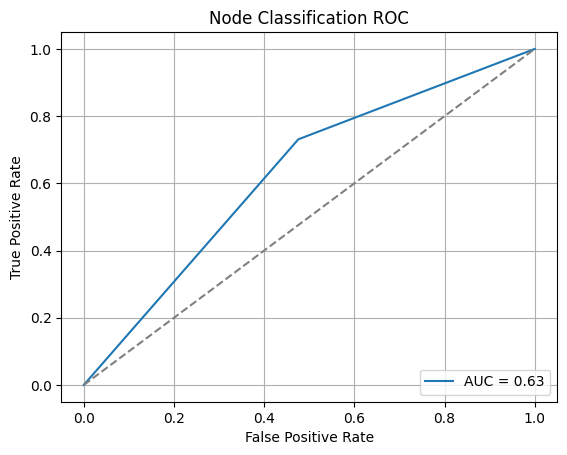

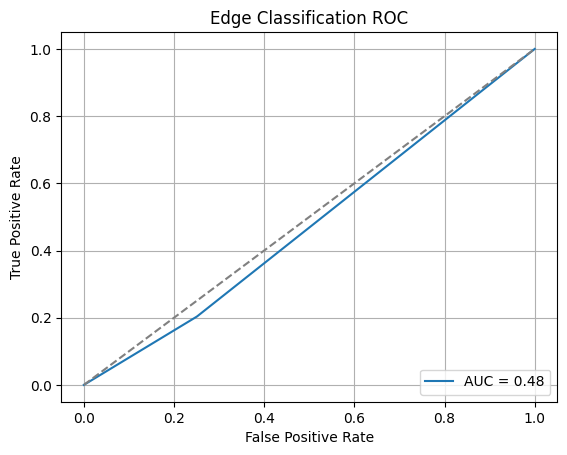

In [10]:
node_scores, node_labels, edge_scores, edge_labels = test_inductive_with_roc(model, test_loader, device=device)

plot_roc_curve(node_labels, node_scores, title='Node Classification ROC')
plot_roc_curve(edge_labels, edge_scores, title='Edge Classification ROC')
